In [31]:
import matplotlib.pyplot as plt

In [32]:
with open('train_data.txt', 'r') as file:
    lines = file.readlines()

In [33]:
x_train = []
y_train = []
labels_train = []

for line in lines:
    x, y, clas = map(float, line.split())
    
    x_train.append(x)
    y_train.append(y)
    labels_train.append(clas)

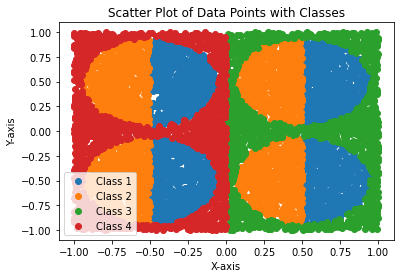

In [34]:
unique_classes = set(labels_train)

for class_value in unique_classes:
    # Get indices of points belonging to the current class
    indices = [i for i, c in enumerate(labels_train) if c == class_value]
    
    # Plot points of the current class with a unique color
    plt.scatter([x_train[i] for i in indices], [y_train[i] for i in indices], label=f'Class {int(class_value)}')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of Data Points with Classes')

# Add legend
plt.legend()
plt.show()

In [35]:
with open('test_data.txt', 'r') as file:
    lines = file.readlines()

In [36]:
x_test = []
y_test = []
labels_test = []

for line in lines:
    x, y, label = map(float, line.split())
    
    x_test.append(x)
    y_test.append(y)
    labels_test.append(label)

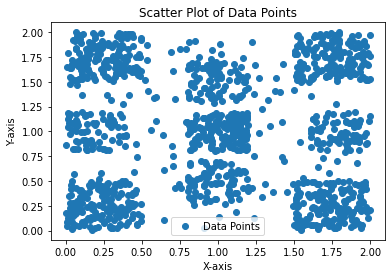

In [37]:
# Create a scatter plot
plt.scatter(x_test, y_test, label='Data Points')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of Data Points')

# Add legend
plt.legend()

# Show the plot
plt.show()

In [89]:
from sklearn.neural_network import MLPClassifier
import numpy as np
from sklearn.metrics import accuracy_score

In [39]:
X = []
for i in range(len(x_train)):
    X.append([x_train[i], y_train[i]])
x_train = np.array(X)
X = []
for i in range(len(x_test)):
    X.append([x_test[i], y_test[i]])
x_test = np.array(X)

y = []
for i in range(len(labels_train)):
    if labels_train[i] == 1:
        y.append([1, 0, 0, 0])
    elif labels_train[i] == 2:
        y.append([0, 1, 0, 0])
    elif labels_train[i] == 3:
        y.append([0, 0, 1, 0])
    elif labels_train[i] == 4:
        y.append([0, 0, 0, 1])
y_train = np.array(y)

y = []
for i in range(len(labels_test)):
    if labels_test[i] == 1:
        y.append([1, 0, 0, 0])
    elif labels_test[i] == 2:
        y.append([0, 1, 0, 0])
    elif labels_test[i] == 3:
        y.append([0, 0, 1, 0])
    elif labels_test[i] == 4:
        y.append([0, 0, 0, 1])
y_test = np.array(y)

In [44]:
clf = MLPClassifier(random_state=1, hidden_layer_sizes=3, max_iter=700, 
                    learning_rate_init=0.01, 
                    batch_size=1, solver='sgd',
                    activation='relu')

In [59]:
clf.fit(x_train, y_train)

MLPClassifier(batch_size=1, hidden_layer_sizes=3, learning_rate_init=0.01,
              max_iter=700, random_state=1, solver='sgd')

In [73]:
y_pred = clf.predict(x_test)
epsilon = 1e-15  # Small constant to avoid log(0) issues
loss = -np.sum(y_test * np.log(y_pred + epsilon))

# Normalize the loss by the number of samples
num_samples = y_test.shape[0]
normalized_loss = loss / num_samples

print("Categorical Crossentropy Loss:", normalized_loss)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

In [85]:
correct = 0
for i in range(len(y_pred)):
    max_index = 0
    for j in range(len(y_pred[i])):
        if y_pred[i][j] > max_index:
            max_index = j + 1
    if max_index == labels_test[i]:
        correct += 1
print("Correct predicted values: ", correct, " out of ", len(y_pred), " samples")
accuracy = correct / len(y_pred)
print("Accuracy: ", accuracy)

718